In [1]:
import os
import pandas as pd
import re

def calculate_average_features_per_interval(output_dir, num_datasets=550):
    intervals = [
        ("Order_3(M1-M2)", 2),
        ("Order_3-4(M1-M12)", 12),
        ("Order_3-5(M1-M68)", 68),
        ("Order_3-6(M1-M545)", 545)
    ]

    interval_sums = {name: 0 for name, _ in intervals}
    valid_file_count = 0 
    
    print(f"开始扫描目录: {output_dir}")
    
    for i in range(num_datasets):
        file_path = os.path.join(output_dir, f"n_{i}_selected_features.csv")

        if not os.path.isfile(file_path):
            continue
            
        try:
            df = pd.read_csv(file_path)

            if 'Selected_Features' not in df.columns:
                print(f"  警告: 文件 {file_path} 缺少 'Selected_Features' 列，跳过。")
                continue
                
            features = df['Selected_Features'].dropna().tolist()

            feature_indices = []
            for f in features:
                match = re.search(r'^M(\d+)$', str(f).strip())
                if match:
                    feature_indices.append(int(match.group(1)))

            for name, max_val in intervals:
                count_in_interval = sum(1 for idx in feature_indices if idx <= max_val)
                interval_sums[name] += count_in_interval
                
            valid_file_count += 1
            
        except Exception as e:
            print(f"  读取文件 {file_path} 时出错: {e}")

    print("\n" + "="*40)
    print(f"=== 统计结果 (共成功处理 {valid_file_count} 个数据集) ===")
    if valid_file_count > 0:
        for name, max_val in intervals:
            avg_count = interval_sums[name] / valid_file_count
            print(f"区间 {name:<20}: 平均保留特征数 = {avg_count:.2f} 个")
    else:
        print("未找到任何有效的结果文件，请检查输入路径。")
    print("="*40)


if __name__ == "__main__":
    OUTPUT_DIR = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\selected_M_features"
    
    calculate_average_features_per_interval(OUTPUT_DIR, num_datasets=550)

开始扫描目录: D:\Orbit_degree_LP\jia\all_3_6\IS0313\selected_M_features

=== 统计结果 (共成功处理 550 个数据集) ===
区间 Order_3(M1-M2)      : 平均保留特征数 = 1.66 个
区间 Order_3-4(M1-M12)   : 平均保留特征数 = 7.57 个
区间 Order_3-5(M1-M68)   : 平均保留特征数 = 20.15 个
区间 Order_3-6(M1-M545)  : 平均保留特征数 = 22.77 个


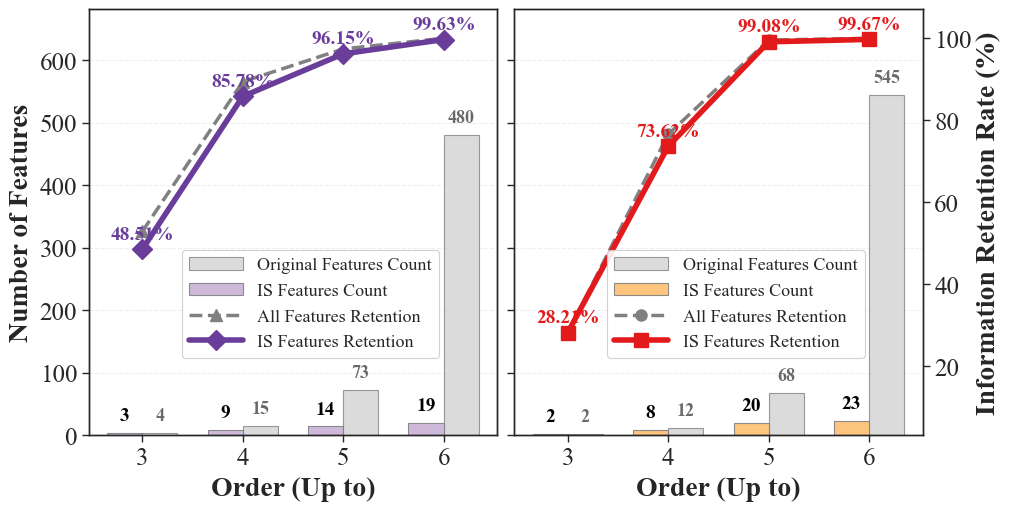

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set(style="ticks", context="paper")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 18
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False 


def get_mean_retention(csv_path, cols):
    if not os.path.exists(csv_path):
        print(f"警告: 找不到文件 {csv_path}。使用默认占位数据以便测试。")
        return [60.0, 75.0, 90.0, 98.0]
        
    df = pd.read_csv(csv_path)
    df = df[~df['Network'].str.contains('AVERAGE|Global', na=False, case=False)].copy()
    
    retentions = []
    for col in cols:
        if col in df.columns:
            mean_loss = df[col].mean()
            retentions.append(100.0 - mean_loss)
        else:
            retentions.append(0.0)
    return retentions

x_labels = ['3', '4', '5', '6']

# --- Node ---
NODE_IS_CSV = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\ISN\reconstruction_loss_summary.csv"
NODE_ALL_CSV = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\all_networks_boundary_loss.csv"
node_cols = ["Order_2-3(N1-N4)", "Order_2-4(N1-N15)", "Order_2-5(N1-N73)", "Order_2-6(N1-N480)"]

node_all_counts = [4, 15, 73, 480] 
node_is_counts = [3, 9, 14, 19]    
node_ret_is = get_mean_retention(NODE_IS_CSV, node_cols)
node_ret_all = get_mean_retention(NODE_ALL_CSV, node_cols)

# --- Edge ---
EDGE_IS_CSV = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\reconstruction_loss_summary.csv"
EDGE_ALL_CSV = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\M_boundary_loss_all_networks.csv"
edge_cols = ["Order_3(M1-M2)", "Order_3-4(M1-M12)", "Order_3-5(M1-M68)", "Order_3-6(M1-M545)"]

edge_all_counts = [2, 12, 68, 545] 
edge_is_counts = [2, 8, 20, 23]    
edge_ret_is = get_mean_retention(EDGE_IS_CSV, edge_cols)
edge_ret_all = get_mean_retention(EDGE_ALL_CSV, edge_cols)

GLOBAL_MAX_COUNT = max(max(node_all_counts), max(edge_all_counts)) * 1.25

all_retentions = node_ret_is + node_ret_all + edge_ret_is + edge_ret_all
GLOBAL_MIN_RET = max(0, min(all_retentions) - 25)

def plot_subplot(ax, x_labels, all_counts, is_counts, ret_is, ret_all, 
                 color_bar_is, color_line_is, marker_is, marker_all,
                 show_left_axis=True, show_right_axis=True,
                 global_max_count=100, global_min_ret=0):
    
    x_p = np.arange(len(x_labels))
    width = 0.35  

    bars_all = ax.bar(x_p + width/2, all_counts, width, label='Original Features Count', 
                      color='lightgrey', edgecolor='grey', alpha=0.8)
    bars_is = ax.bar(x_p - width/2, is_counts, width, label='IS Features Count', 
                     color=color_bar_is, edgecolor='grey', alpha=0.9)
                     
    ax.set_xlabel('Order (Up to)', fontweight='bold')
    
    ax.set_ylim(0, global_max_count) 

    if show_left_axis:
        ax.set_ylabel('Number of Features', fontweight='bold')
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
        ax.tick_params(axis='y', left=False)

    ax_twin = ax.twinx()
    
    line_all = ax_twin.plot(x_p, ret_all, color='grey', marker=marker_all, 
                            linestyle='--', linewidth=2.5, markersize=8, label='All Features Retention')
    line_is = ax_twin.plot(x_p, ret_is, color=color_line_is, marker=marker_is, 
                           linestyle='-', linewidth=4, markersize=10, label='IS Features Retention')

    ax_twin.set_ylim(global_min_ret, 107)

    if show_right_axis:
        ax_twin.set_ylabel('Information Retention Rate (%)', fontweight='bold')
    else:
        ax_twin.set_ylabel('')
        ax_twin.set_yticklabels([])
        ax_twin.tick_params(axis='y', right=False)

    ax.set_xticks(x_p)
    ax.set_xticklabels(x_labels)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    local_max = max(all_counts)
    for bar in bars_all:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + global_max_count*0.02, f'{height}', 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='dimgrey')
                
    for bar in bars_is:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + global_max_count*0.02, f'{height}', 
                ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')
        
    for i, v in enumerate(ret_is):
        ax_twin.text(i, v + 2.5, f'{v:.2f}%', ha='center', color=color_line_is, 
                     fontweight='bold', fontsize=14)

    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax_twin.get_legend_handles_labels()
    
    ax_twin.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', 
                   bbox_to_anchor=(0.88, 0.16), framealpha=0.9, fontsize=13, 
                   handlelength=3)

    return ax_twin

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

ax_node = plot_subplot(axes[0], x_labels, node_all_counts, node_is_counts, node_ret_is, node_ret_all, 
                       color_bar_is='#CAB2D6', color_line_is='#6A3D9A',
                       marker_is='D', marker_all='^',
                       show_left_axis=True, show_right_axis=False,
                       global_max_count=GLOBAL_MAX_COUNT, global_min_ret=GLOBAL_MIN_RET) # ✨ 传入全局约束

ax_edge = plot_subplot(axes[1], x_labels, edge_all_counts, edge_is_counts, edge_ret_is, edge_ret_all, 
                       color_bar_is='#FDBF6F', color_line_is='#E31A1C',
                       marker_is='s', marker_all='o',
                       show_left_axis=False, show_right_axis=True,
                       global_max_count=GLOBAL_MAX_COUNT, global_min_ret=GLOBAL_MIN_RET) # ✨ 传入全局约束


png_path = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\Compression_Retention_Dual_UnifiedScale.pdf"
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()

Starting Sequential Analysis (Information Retention)...
Preparing full feature matrix (Ground Truth, 480 features)...
Step 01 | Added: N1    | Info Retention: 57.79% (↑)
Step 02 | Added: N3    | Info Retention: 74.85% (↑)
Step 03 | Added: N5    | Info Retention: 81.09% (↑)
Step 04 | Added: N6    | Info Retention: 86.70% (↑)
Step 05 | Added: N7    | Info Retention: 88.85% (↑)
Step 06 | Added: N12   | Info Retention: 93.59% (↑)
Step 07 | Added: N16   | Info Retention: 94.86% (↑)
Step 08 | Added: N23   | Info Retention: 96.53% (↑)
Step 09 | Added: N53   | Info Retention: 97.51% (↑)
Step 10 | Added: N91   | Info Retention: 98.06% (↑)
Step 11 | Added: N131  | Info Retention: 98.42% (↑)
Step 12 | Added: N143  | Info Retention: 98.74% (↑)
Step 13 | Added: N216  | Info Retention: 99.11% (↑)
Step 14 | Added: N291  | Info Retention: 99.33% (↑)


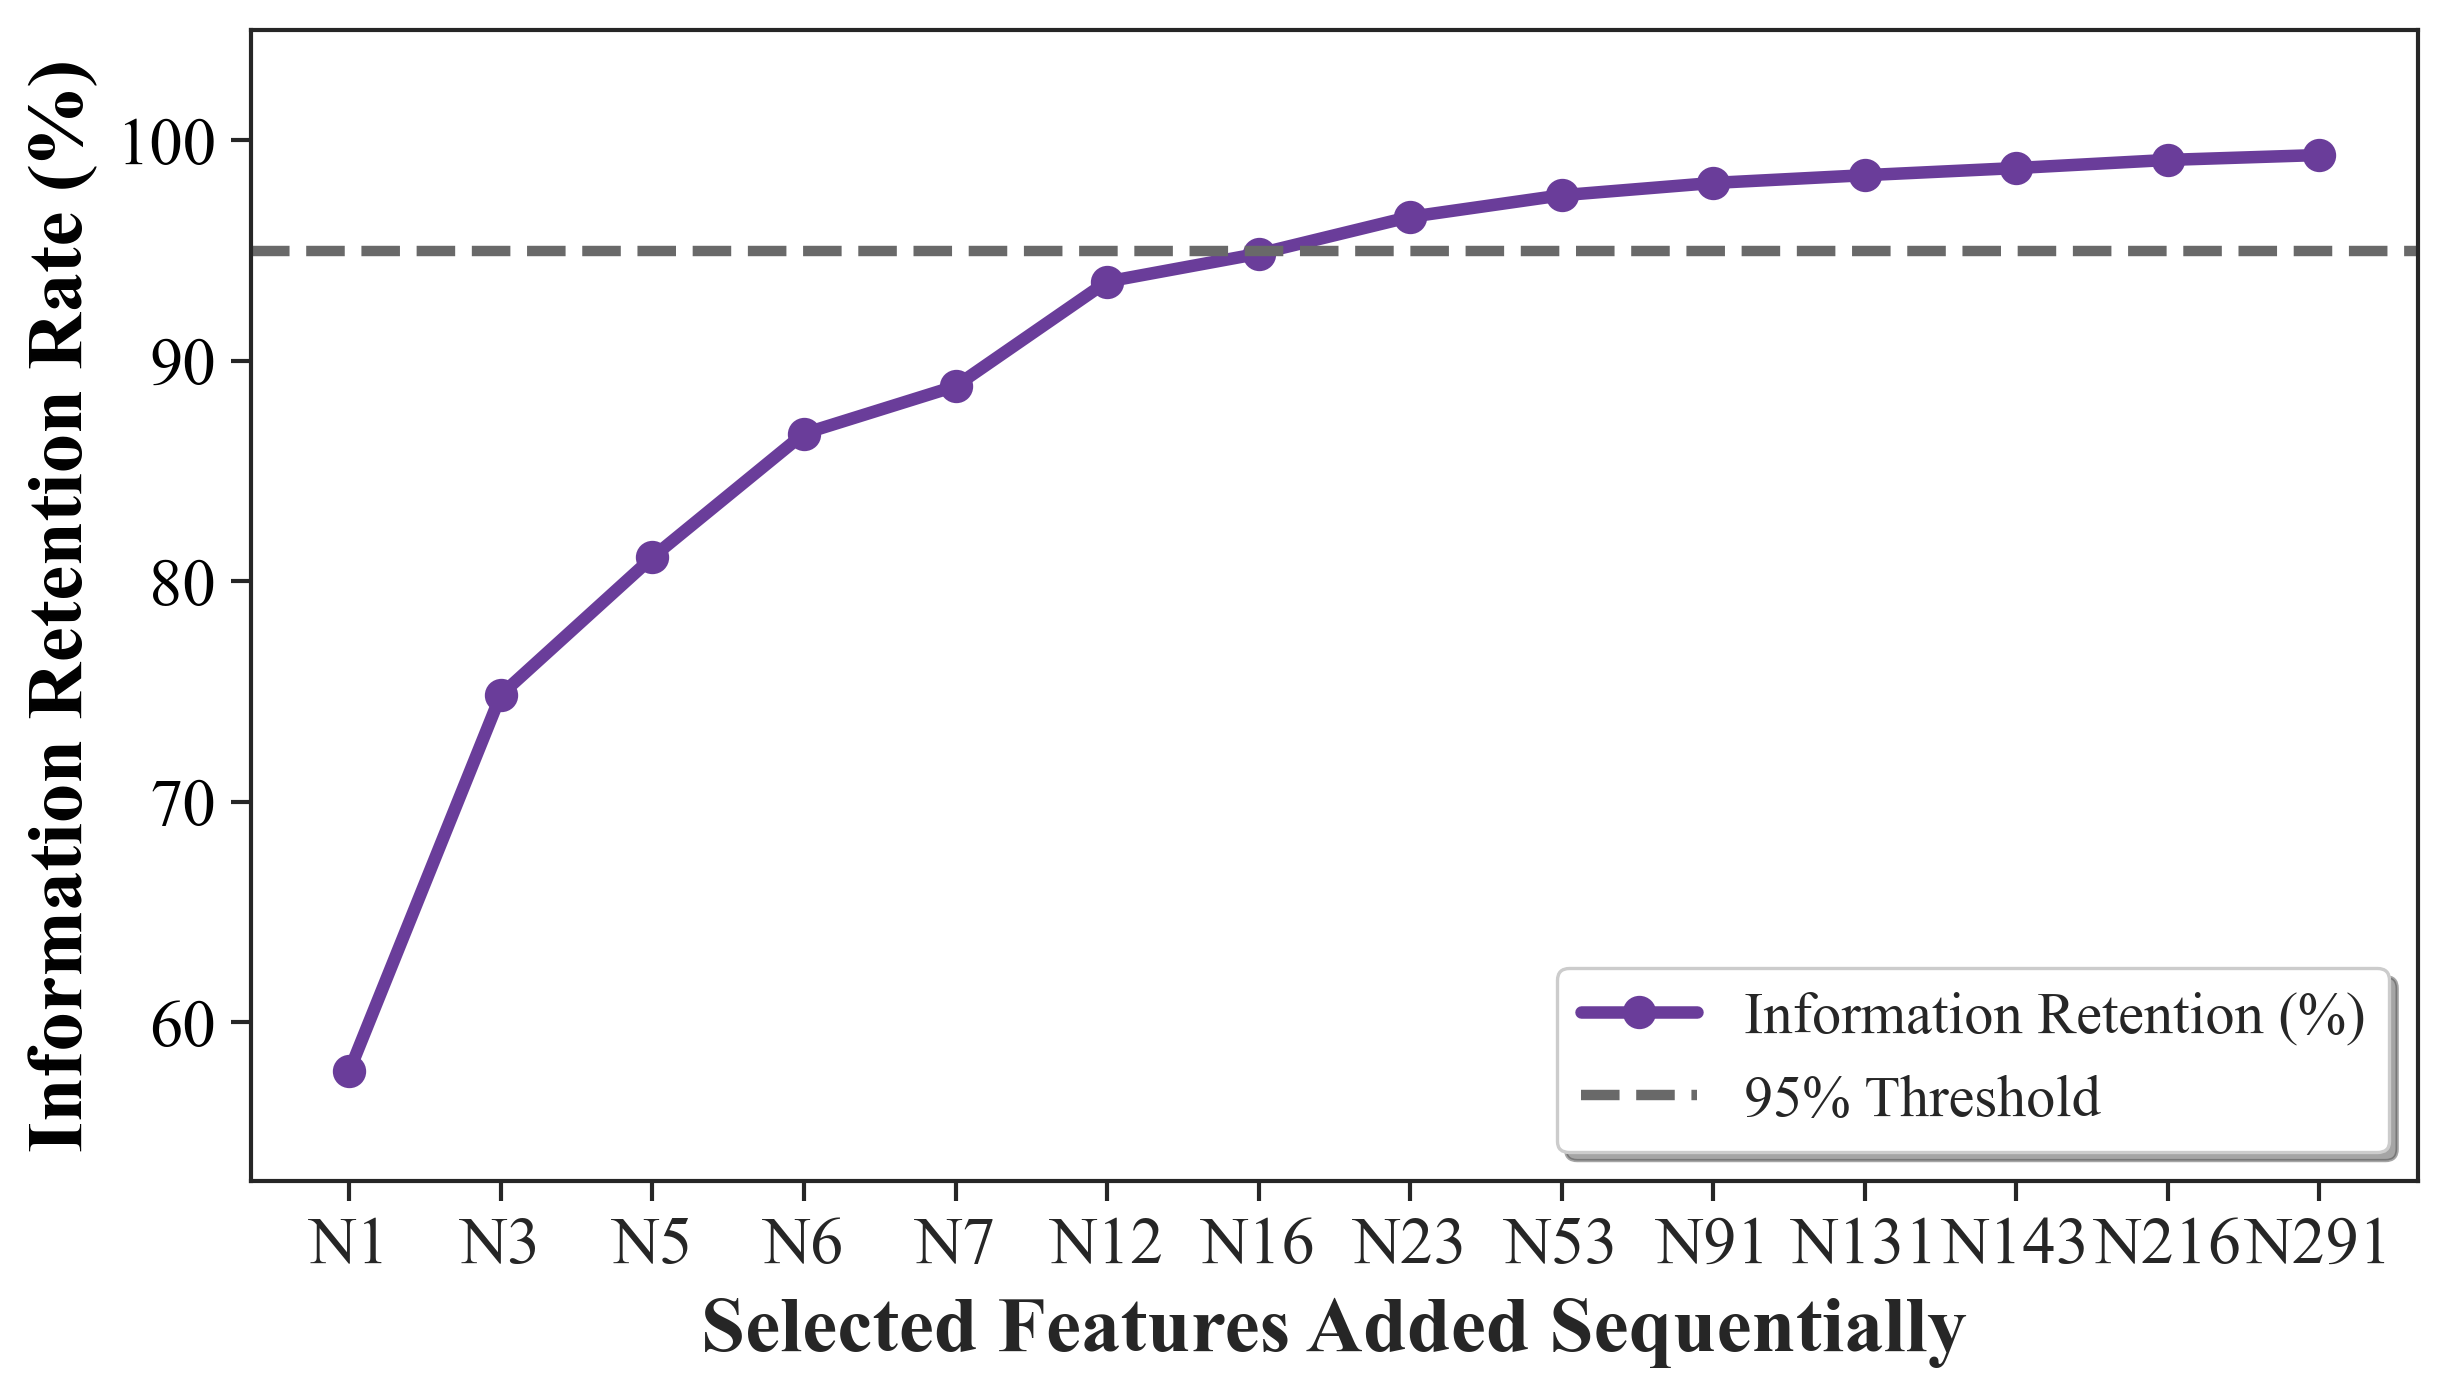

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge 
import warnings
from sklearn.preprocessing import PolynomialFeatures
import os

sns.set_style("ticks") 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.dpi'] = 300 
warnings.filterwarnings('ignore')

DATA_PATH = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\n_1_node_features.csv"
SELECTED_FEATURES_PATH = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\ISN\selected_N_features\n_1_selected_features.csv"
 
SAMPLE_SIZE_LOSS = 2000          

def calculate_reconstruction_loss(X_sub, X_full):
    poly = PolynomialFeatures(degree=2, include_bias=True) 
    X_sub_poly = poly.fit_transform(X_sub)
    
    scaler = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub_poly)
    
    reg = Ridge(alpha=0.01)
    reg.fit(X_sub_scaled, X_full)
    X_full_pred = reg.predict(X_sub_scaled)
    
    error_norm = np.linalg.norm(X_full - X_full_pred, ord='fro')
    base_norm = np.linalg.norm(X_full, ord='fro')
    
    if base_norm == 0:
        return 0.0
    return error_norm / base_norm

def run_sequential_analysis(df, candidate_features, full_features):
    print(f"Starting Sequential Analysis (Information Retention)...")
    
    if len(df) > SAMPLE_SIZE_LOSS:
        df_sample = df.sample(n=SAMPLE_SIZE_LOSS, random_state=42)
    else:
        df_sample = df
    
    scaler = StandardScaler()
    print(f"Preparing full feature matrix (Ground Truth, {len(full_features)} features)...")
    X_full = scaler.fit_transform(df_sample[full_features].values)
    
    selected_sequence = []
    loss_history = []
    
    current_features = []
    max_steps = len(candidate_features)
    
    for step in range(max_steps):
        best_feat = candidate_features[step]
        current_features.append(best_feat)
        selected_sequence.append(best_feat)

        X_sub = df_sample[current_features].values
        X_sub = scaler.fit_transform(X_sub) 
        
        loss = calculate_reconstruction_loss(X_sub, X_full)
        loss_history.append(loss)

        retention = (1.0 - loss) * 100
        print(f"Step {step+1:02d} | Added: {best_feat:<5} | Info Retention: {retention:.2f}% (↑)")

    return selected_sequence, loss_history

def plot_sequential_analysis(selected_feats, loss):
    fig, ax1 = plt.subplots(figsize=(8.5, 5)) 

    retention_pct = [(1.0 - l) * 100 for l in loss]
    color_retention = '#6A3D9A' 

    ax1.set_xlabel('Selected Features Added Sequentially', fontsize=19, fontweight='bold', labelpad=5)
    ax1.set_ylabel('Information Retention Rate (%)', color='black', fontsize=19, fontweight='bold')
    
    x_positions = np.arange(len(selected_feats))
    
    line1, = ax1.plot(x_positions, retention_pct, 'o-', color=color_retention, linewidth=3, 
                      markersize=7, label='Information Retention (%)')
    
    color_threshold = 'dimgray'
    line2 = ax1.axhline(y=95.0, color=color_threshold, linestyle='--', linewidth=2.5, label='95% Threshold')
    
    ax1.set_xticks(x_positions)

    ax1.set_xticklabels(selected_feats, fontsize=16)

    ax1.tick_params(axis='x', bottom=True, labelsize=16)
    ax1.tick_params(axis='y', left=True, labelcolor='black', labelsize=16)
    
    ax1.set_ylim(min(retention_pct)-5, 105) 
    ax1.grid(False) 

    lines = [line1, line2]
    labels = [l.get_label() for l in lines]

    ax1.legend(lines, labels, loc='lower right', frameon=True, shadow=True, fancybox=True, fontsize=14)

    plt.tight_layout()
    
    file_dir = os.path.dirname(SELECTED_FEATURES_PATH)
    save_path = os.path.join(file_dir, "Information_Retention_Curve_DPI300.pdf")
    
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

if __name__ == "__main__":
    if not os.path.exists(DATA_PATH) or not os.path.exists(SELECTED_FEATURES_PATH):
        print("错误: 文件路径不存在，请检查配置区域。")
    else:
        df = pd.read_csv(DATA_PATH)
        is_df = pd.read_csv(SELECTED_FEATURES_PATH)

        is_features = is_df.iloc[:, 0].tolist()
        is_features = [f for f in is_features if f in df.columns]

        full_features = [f"N{i}" for i in range(1, 481) if f"N{i}" in df.columns]

        best_order, loss = run_sequential_analysis(df, is_features, full_features)
        plot_sequential_analysis(best_order, loss)

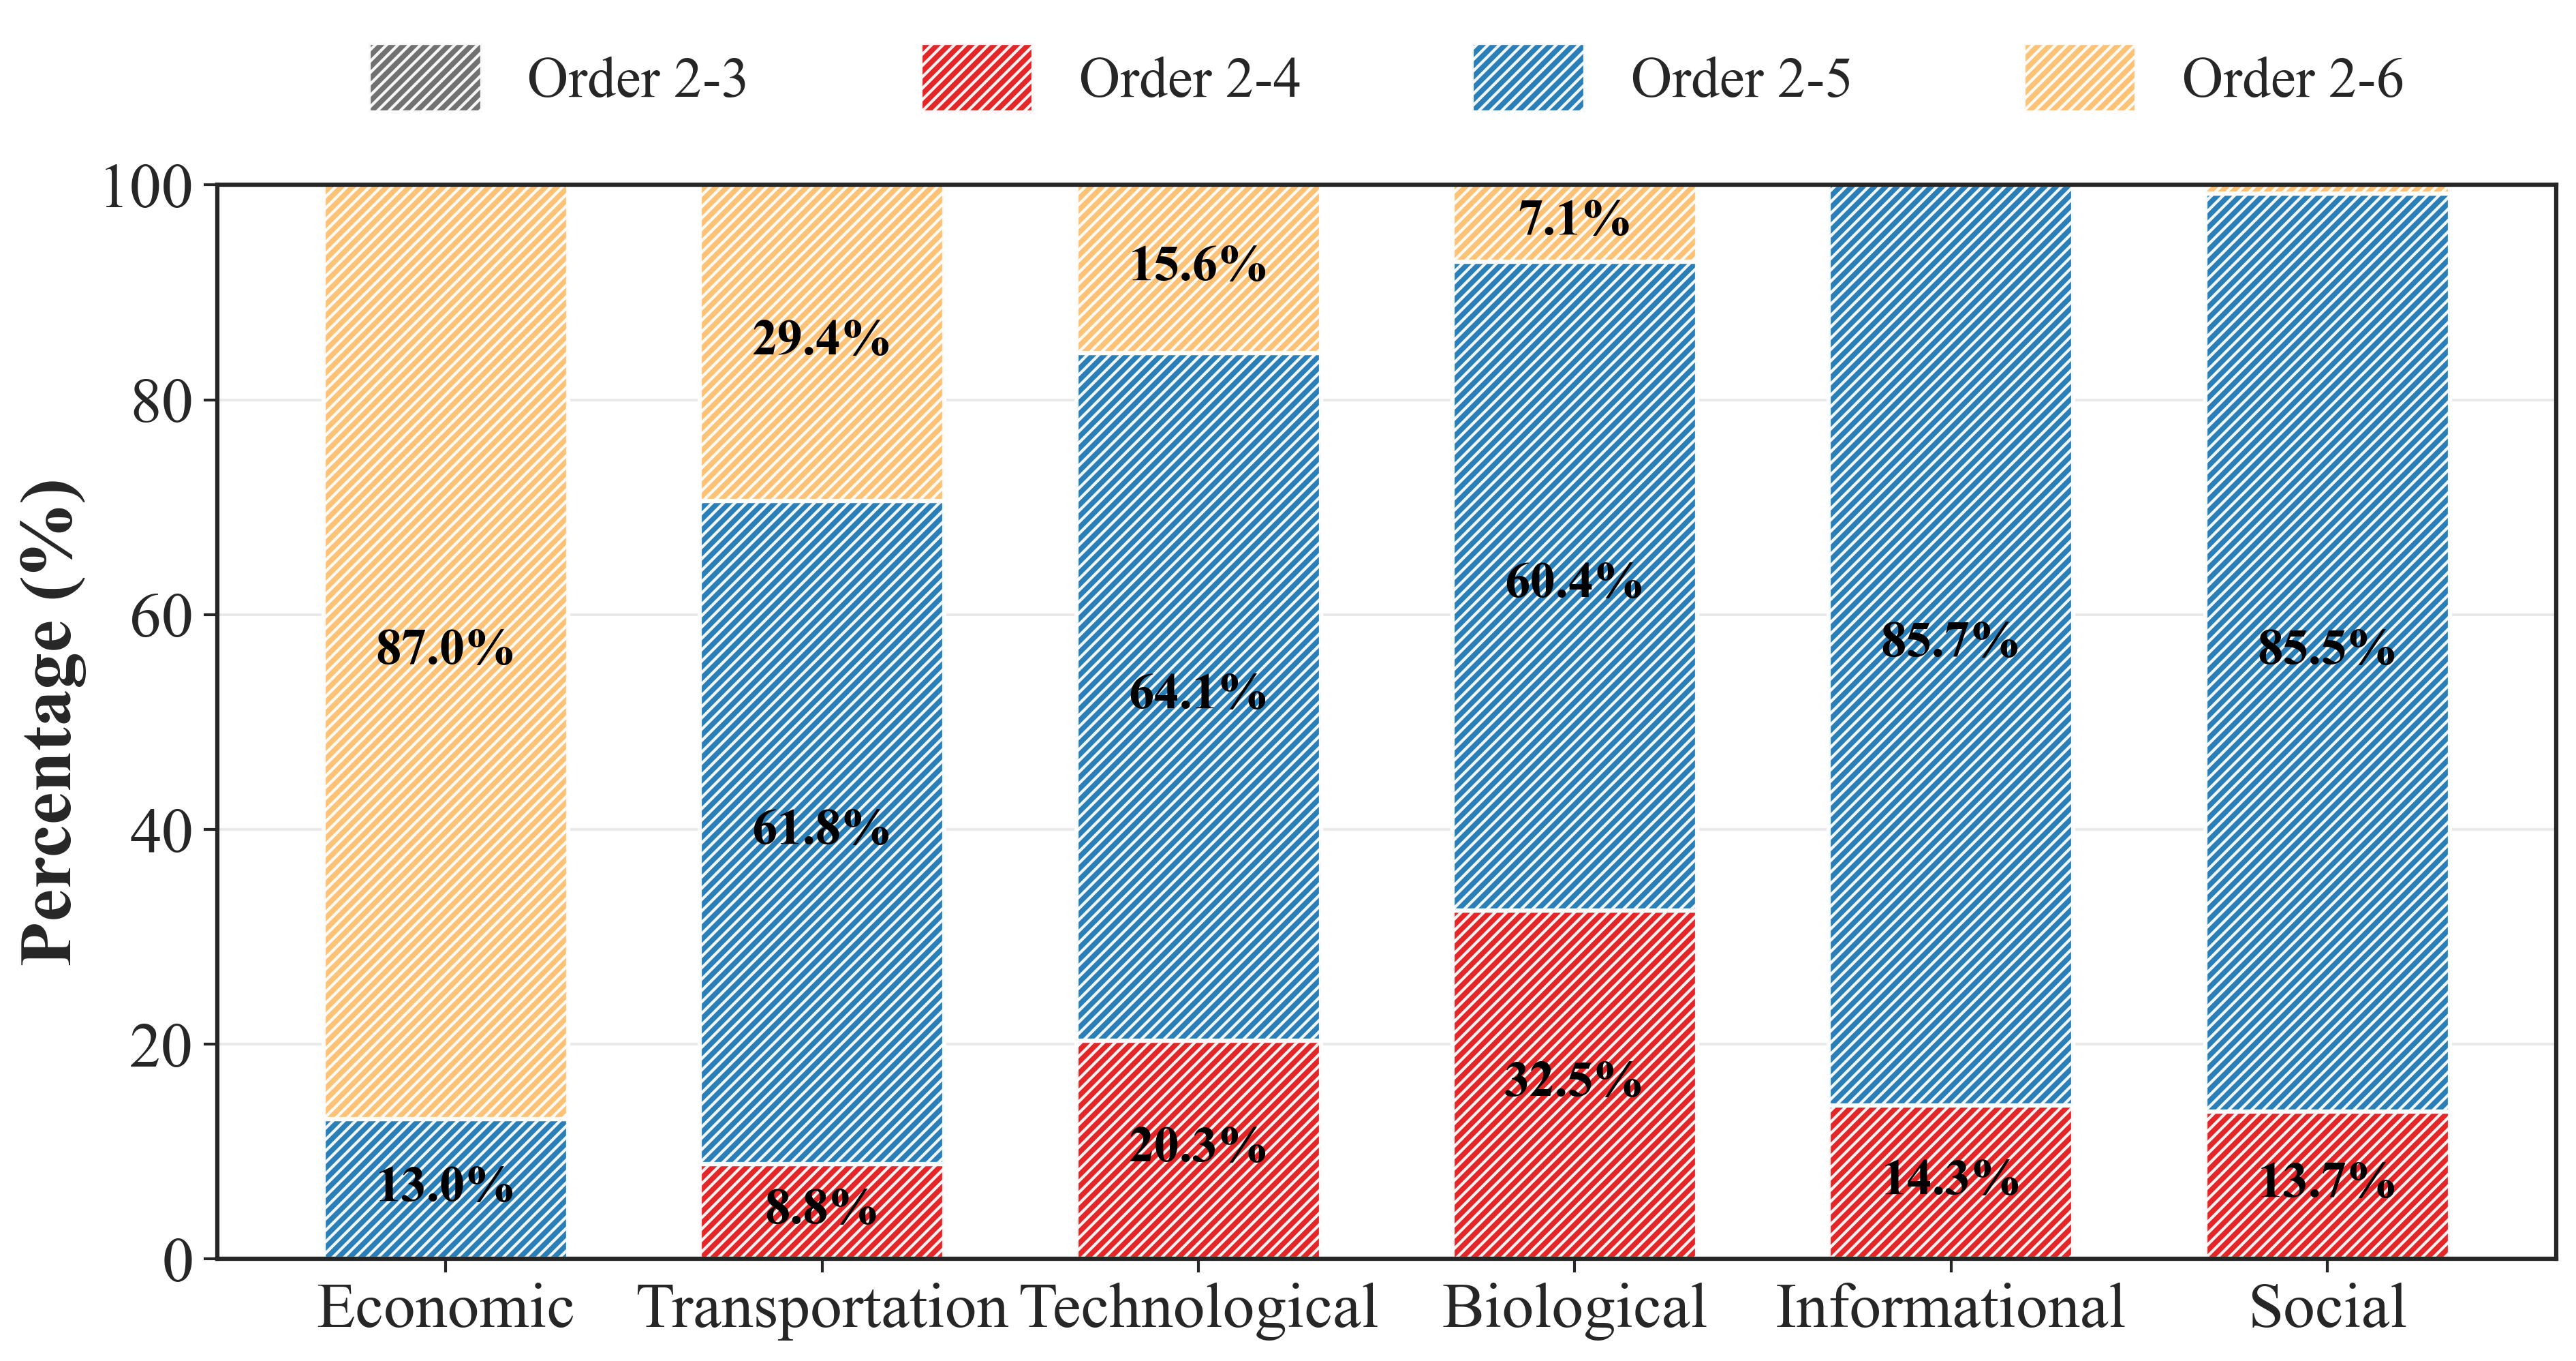

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

# --- 1. 配置路径 ---
IS_DIR = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features"
INPUT_CSV = os.path.join(IS_DIR, "boundary_95_network_max_motif_classification.csv")
PNG_OUTPUT = os.path.join(IS_DIR, "domain_comparison_original_stripe.png")
PDF_OUTPUT = os.path.join(IS_DIR, "domain_comparison_pastel_colors.pdf")

SIZE_TITLE  = 26 
SIZE_TICKS  = 22.5 
SIZE_LEGEND = 20 
SIZE_LABEL  = 18

ORDER_LEVELS = ["2-3", "2-4", "2-5", "2-6"]

COLORS = {
    "2-3": "#696969",
    "2-4": "#E31A1C", 
    "2-5": "#1F78B4", 
    "2-6": "#FDBF6F" 
}

CAT_MAP = {
    "2-3 (最高N4)": "2-3",
    "2-4 (最高N15)": "2-4",
    "2-5 (最高N73)": "2-5",
    "2-6 (最高N480)": "2-6"
}

HATCH_STYLE = "///"

TARGET_DOMAINS = [
    "Economic", 
    "Transportation", 
    "Technological",
    "Biological",  
    "Informational", 
    "Social"
]

def main():
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['axes.linewidth'] = 1.5 

    if not os.path.exists(INPUT_CSV):
        print(f"找不到文件: {INPUT_CSV}")

    else:
        df = pd.read_csv(INPUT_CSV)
        plot_data = {}
        valid_x_labels = [] 
        
        for domain in TARGET_DOMAINS:
            sub_df = df[df['network_domain'] == domain]
            total = len(sub_df)
            domain_props = {order: 0.0 for order in ORDER_LEVELS}
            
            if total > 0:
                counts = sub_df['Category'].value_counts()
                for long_cat, count in counts.items():
                    short_cat = CAT_MAP.get(long_cat)
                    if short_cat:
                        domain_props[short_cat] = (count / total) * 100
            
            plot_data[domain] = domain_props
            valid_x_labels.append(domain)

    fig, ax = plt.subplots(figsize=(13, 7), dpi=300) 
    
    x = np.arange(len(valid_x_labels))
    width = 0.65  

    bottoms = np.zeros(len(valid_x_labels))

    for order in ORDER_LEVELS:
        heights = [plot_data[d][order] for d in valid_x_labels]
        c = COLORS[order]

        bars = ax.bar(x, heights, width, 
                      color=c,            
                      bottom=bottoms, 
                      edgecolor='white',     
                      hatch=HATCH_STYLE * 2, 
                      linewidth=1.5,
                      alpha=0.95,        
                      label=f'Order {order}')
        
        for i, bar in enumerate(bars):
            h = bar.get_height()
            if h > 4:  
                text_color = 'black' 

                ax.text(bar.get_x() + bar.get_width() / 2, 
                        bottoms[i] + h / 2, 
                        f'{h:.1f}%', 
                        ha='center', va='center', 
                        color=text_color,
                        fontsize=SIZE_LABEL, fontweight='bold')
        
        bottoms += heights

    ax.set_xticks(x)
    ax.set_xticklabels(valid_x_labels, fontsize=SIZE_TICKS)
    ax.set_ylabel("Percentage (%)", fontsize=SIZE_TITLE, fontweight='bold')
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels(np.arange(0, 101, 20), fontsize=SIZE_TICKS)
    ax.set_ylim(0, 100)
    
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='-', color='#E0E0E0', alpha=0.7, linewidth=1)

    ax.legend(loc='lower center', 
              bbox_to_anchor=(0.5, 1.02),
              ncol=4,  
              frameon=False, 
              fontsize=SIZE_LEGEND, 
              columnspacing=3.0,
              handlelength=2.0,
              handleheight=1.5)

    
    plt.tight_layout()

    #plt.savefig(PDF_OUTPUT, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()

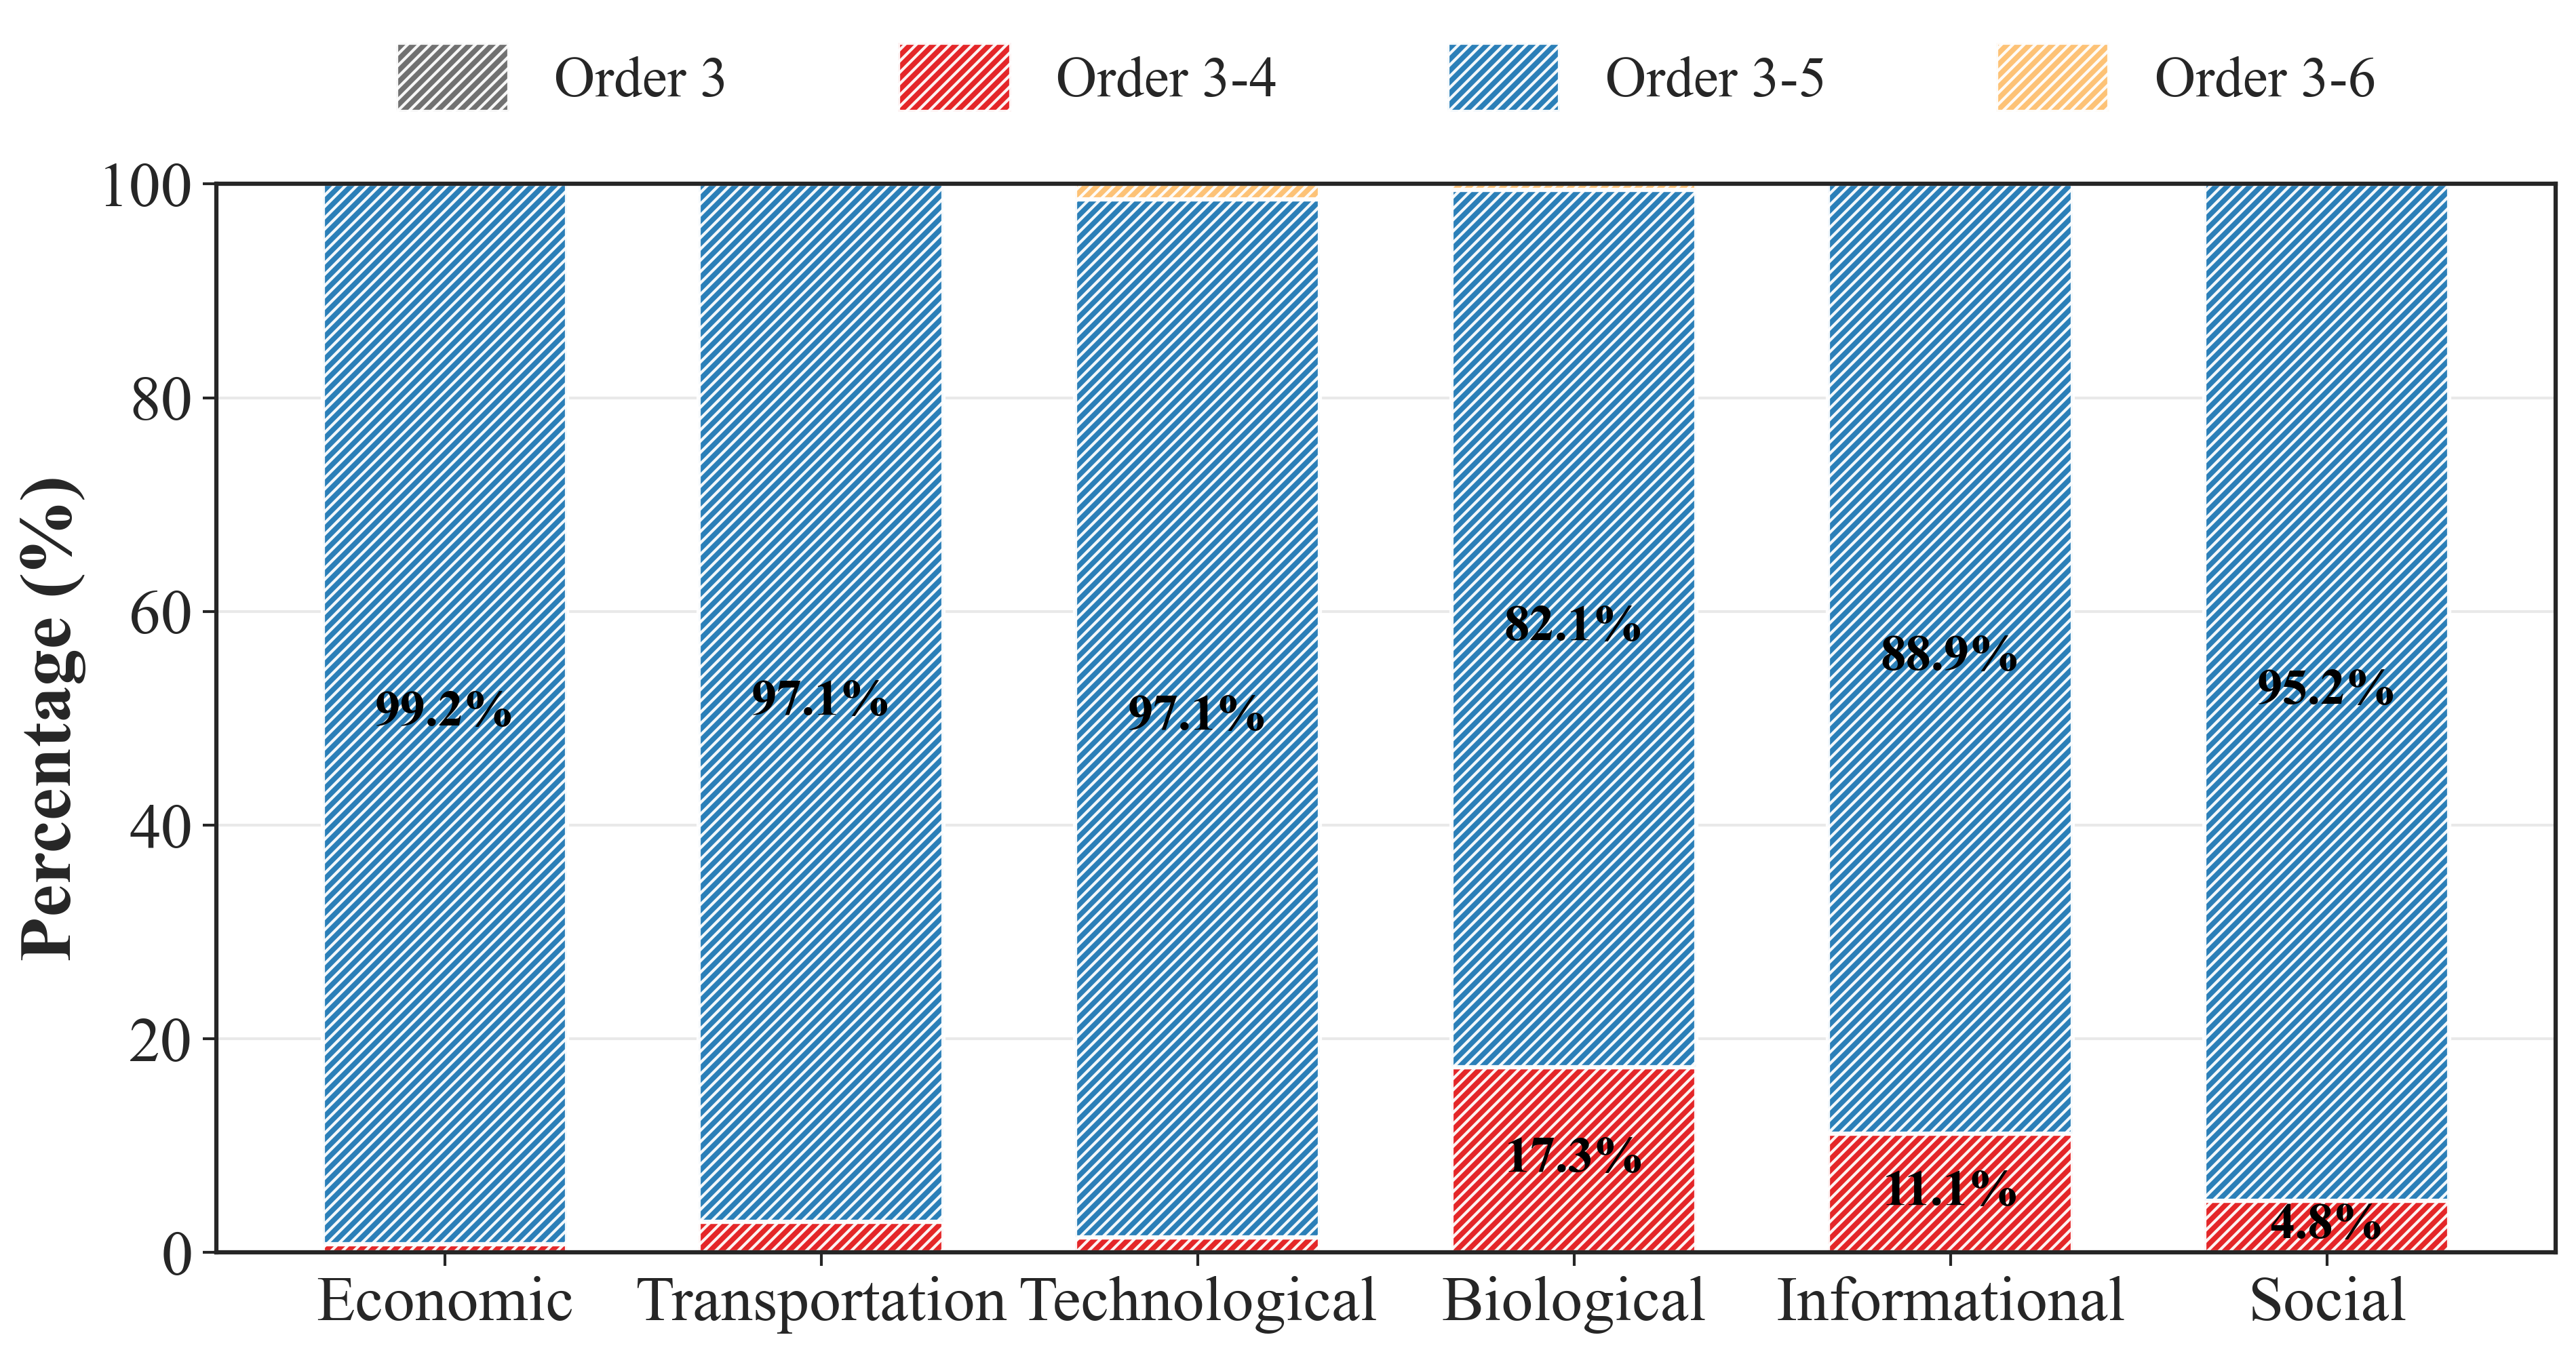

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

IS_DIR = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313"
INPUT_CSV = os.path.join(IS_DIR, "boundary_95_network_max_motif_classification.csv")
PNG_OUTPUT = os.path.join(IS_DIR, "domain_comparison_original_stripe.png")
PDF_OUTPUT = os.path.join(IS_DIR, "domain_comparison_pastel_colors.pdf")

SIZE_TITLE  = 26  
SIZE_TICKS  = 22.5 
SIZE_LEGEND = 20  
SIZE_LABEL  = 18  

ORDER_LEVELS = ["3", "3-4", "3-5", "3-6"]

COLORS = {
    "3":   "#696969", 
    "3-4": "#E31A1C", 
    "3-5": "#1F78B4", 
    "3-6": "#FDBF6F" 
}

CAT_MAP = {
    "3 (最高M2)": "3",
    "3-4 (最高M12)": "3-4",
    "3-5 (最高M68)": "3-5",
    "3-6 (最高M545)": "3-6"
}

HATCH_STYLE = "///" 

TARGET_DOMAINS = [
    "Economic", 
    "Transportation", 
    "Technological",
    "Biological",  
    "Informational", 
    "Social"
]

def main():
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['axes.linewidth'] = 1.5 
    
    if not os.path.exists(INPUT_CSV):
        print(f" 找不到文件: {INPUT_CSV}")

    else:
        df = pd.read_csv(INPUT_CSV)
        plot_data = {}
        valid_x_labels = [] 
        
        for domain in TARGET_DOMAINS:
            sub_df = df[df['network_domain'] == domain]
            total = len(sub_df)
            domain_props = {order: 0.0 for order in ORDER_LEVELS}
            
            if total > 0:
                counts = sub_df['Category'].value_counts()
                for long_cat, count in counts.items():
                    short_cat = CAT_MAP.get(long_cat)
                    if short_cat:
                        domain_props[short_cat] = (count / total) * 100
            
            plot_data[domain] = domain_props
            valid_x_labels.append(domain)

    fig, ax = plt.subplots(figsize=(13, 7), dpi=300) 
    
    x = np.arange(len(valid_x_labels))
    width = 0.65  

    bottoms = np.zeros(len(valid_x_labels))

    for order in ORDER_LEVELS:
        heights = [plot_data[d][order] for d in valid_x_labels]
        c = COLORS[order]

        bars = ax.bar(x, heights, width, 
                      color=c,            
                      bottom=bottoms, 
                      edgecolor='white',     
                      hatch=HATCH_STYLE * 2,  
                      linewidth=1.5,
                      alpha=0.95,        
                      label=f'Order {order}')
        
        for i, bar in enumerate(bars):
            h = bar.get_height()
            if h > 4:  
                text_color = 'black' 

                ax.text(bar.get_x() + bar.get_width() / 2, 
                        bottoms[i] + h / 2, 
                        f'{h:.1f}%', 
                        ha='center', va='center', 
                        color=text_color,
                        fontsize=SIZE_LABEL, fontweight='bold')
        
        bottoms += heights

    ax.set_xticks(x)
    ax.set_xticklabels(valid_x_labels, fontsize=SIZE_TICKS)
    ax.set_ylabel("Percentage (%)", fontsize=SIZE_TITLE, fontweight='bold')
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels(np.arange(0, 101, 20), fontsize=SIZE_TICKS)
    ax.set_ylim(0, 100)
    
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='-', color='#E0E0E0', alpha=0.7, linewidth=1)

    ax.legend(loc='lower center', 
              bbox_to_anchor=(0.5, 1.02),
              ncol=4,  
              frameon=False, 
              fontsize=SIZE_LEGEND, 
              columnspacing=3.0,
              handlelength=2.0,
              handleheight=1.5)

    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    
    plt.tight_layout()

    #plt.savefig(PDF_OUTPUT, bbox_inches='tight')

    plt.show()

if __name__ == "__main__":
    main()

热力图已保存: 
 - D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\domain_motif_fingerprint.png
 - D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\domain_motif_fingerprint.pdf


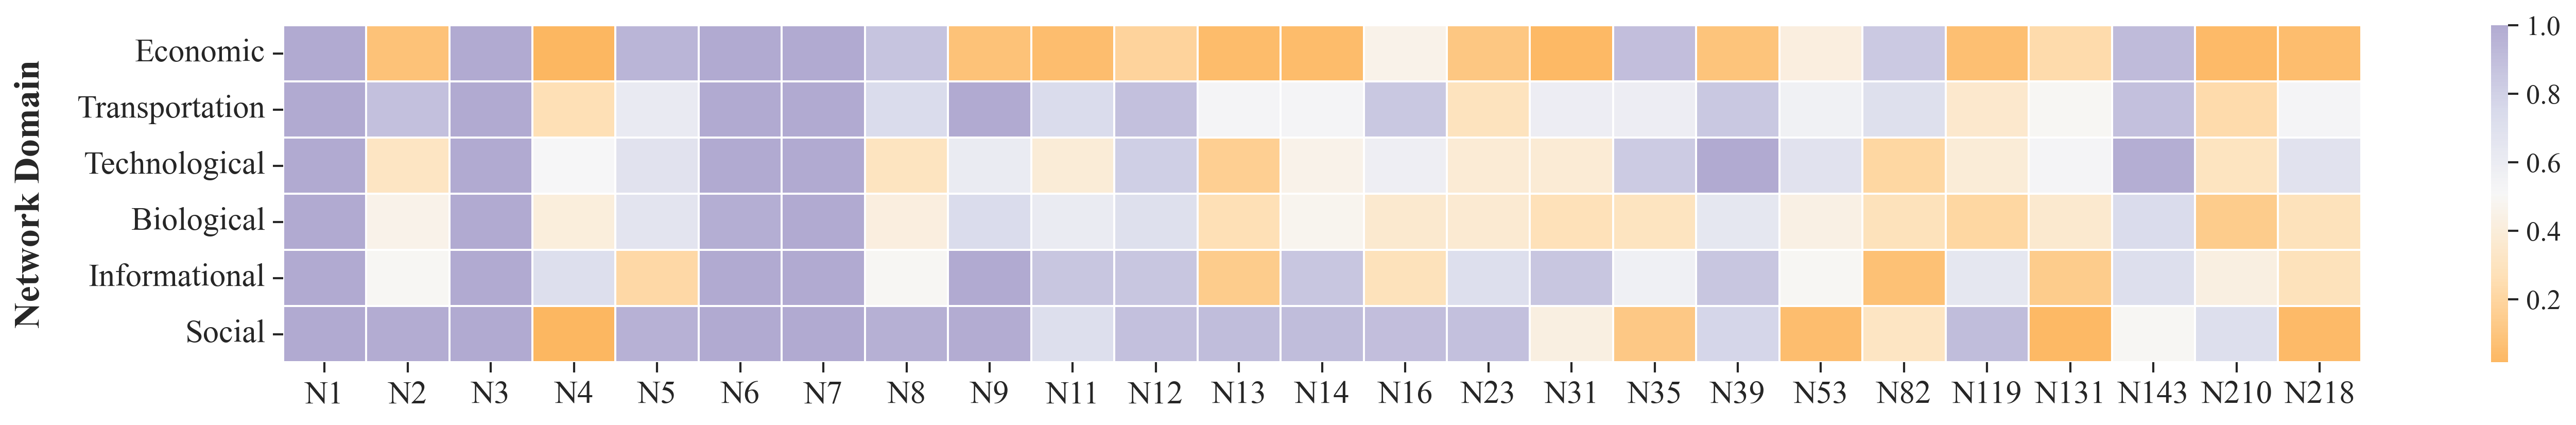

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import re
import numpy as np
import warnings

warnings.filterwarnings('ignore')

IS_DIR = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features"
FEATURES_DIR=r"D:\Orbit_degree_LP\jia\all_3_6\IS0313\node_features\ISN\selected_N_features"

INFO_FILE = os.path.join(IS_DIR, "network_max_motif_classification.csv")

OUTPUT_IMG = os.path.join(IS_DIR, "domain_motif_fingerprint.png")
OUTPUT_PDF = os.path.join(IS_DIR, "domain_motif_fingerprint.pdf")

TOP_N_MOTIFS = 25 

TARGET_DOMAINS = [
    "Economic", 
    "Transportation", 
    "Technological",
    "Biological",  
    "Informational", 
    "Social"
]

def get_m_indices(file_path):
    if not os.path.exists(file_path): 
        return []
    try:
        df = pd.read_csv(file_path)

        if 'Selected_Features' not in df.columns:
            return []
            
        feats = df['Selected_Features'].tolist()
        indices = []
        for f in feats:
            match = re.search(r'\d+', str(f))
            if match: 
                indices.append(int(match.group()))
        return indices
    except Exception as e: 
        print(f"读取 {file_path} 失败: {e}")
        return []

def main():
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 15        
    plt.rcParams['axes.titlesize'] = 17    
    plt.rcParams['axes.labelsize'] = 17    
    plt.rcParams['xtick.labelsize'] = 15   
    plt.rcParams['ytick.labelsize'] = 15  

    if not os.path.exists(INFO_FILE):
        print(f"找不到包含领域信息的汇总表: {INFO_FILE}")
        return

    df_info = pd.read_csv(INFO_FILE)
    if 'network_domain' not in df_info.columns or 'Network' not in df_info.columns:
        print("INFO_FILE 中缺少 'Network' 或 'network_domain' 列")
        return

    id_to_domain = dict(zip(df_info['Network'], df_info['network_domain']))

    domain_motif_counts = {}
    domain_sizes = {}
    
    for net_name, domain in id_to_domain.items():
        domain = str(domain).strip()
        if pd.isna(domain) or domain == 'nan' or domain == 'Unknown' or domain == '': 
            continue

        if domain not in domain_motif_counts:
            domain_motif_counts[domain] = {}
            domain_sizes[domain] = 0
            
        domain_sizes[domain] += 1

        f_path = os.path.join(FEATURES_DIR, f"{net_name}_selected_features.csv")
        
        m_indices = get_m_indices(f_path)
        for m in m_indices:
            domain_motif_counts[domain][m] = domain_motif_counts[domain].get(m, 0) + 1

    if not domain_motif_counts:
        print("没有提取到任何模体数据。")
        return

    df_counts = pd.DataFrame(domain_motif_counts).fillna(0).T
    df_freq = df_counts.copy()
    
    for domain in df_freq.index:
        size = domain_sizes.get(domain, 1)
        if size > 0:
            df_freq.loc[domain] = df_freq.loc[domain] / size

    motif_mean_freq = df_freq.mean(axis=0)
    top_motifs = motif_mean_freq.nlargest(TOP_N_MOTIFS).index.tolist()
    top_motifs.sort() 
    
    df_heatmap = df_freq[top_motifs]
    df_heatmap.columns = [f"N{c}" for c in df_heatmap.columns]

    valid_domains = [d for d in TARGET_DOMAINS if d in df_heatmap.index]
    df_heatmap = df_heatmap.loc[valid_domains]

    plt.figure(figsize=(19, 3), dpi=300)

    cmap_original = plt.get_cmap('PuOr')
    new_colors = cmap_original(np.linspace(0.3, 0.7, 256))
    custom_cmap = mcolors.ListedColormap(new_colors)

    ax = sns.heatmap(df_heatmap, annot=False, 
                cmap=custom_cmap,      
                linewidths=.5) 

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13) 

    plt.ylabel("Network Domain", labelpad=14, fontweight='bold')
    
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    #plt.savefig(OUTPUT_IMG, bbox_inches='tight')
    #plt.savefig(OUTPUT_PDF, bbox_inches='tight')
    print(f"热力图已保存: \n - {OUTPUT_IMG}\n - {OUTPUT_PDF}")
    plt.show()

if __name__ == "__main__":
    main()

热力图已保存: 
 - D:\Orbit_degree_LP\jia\all_3_6\IS0313\domain_motif_fingerprint.png
 - D:\Orbit_degree_LP\jia\all_3_6\IS0313\domain_motif_fingerprint.pdf


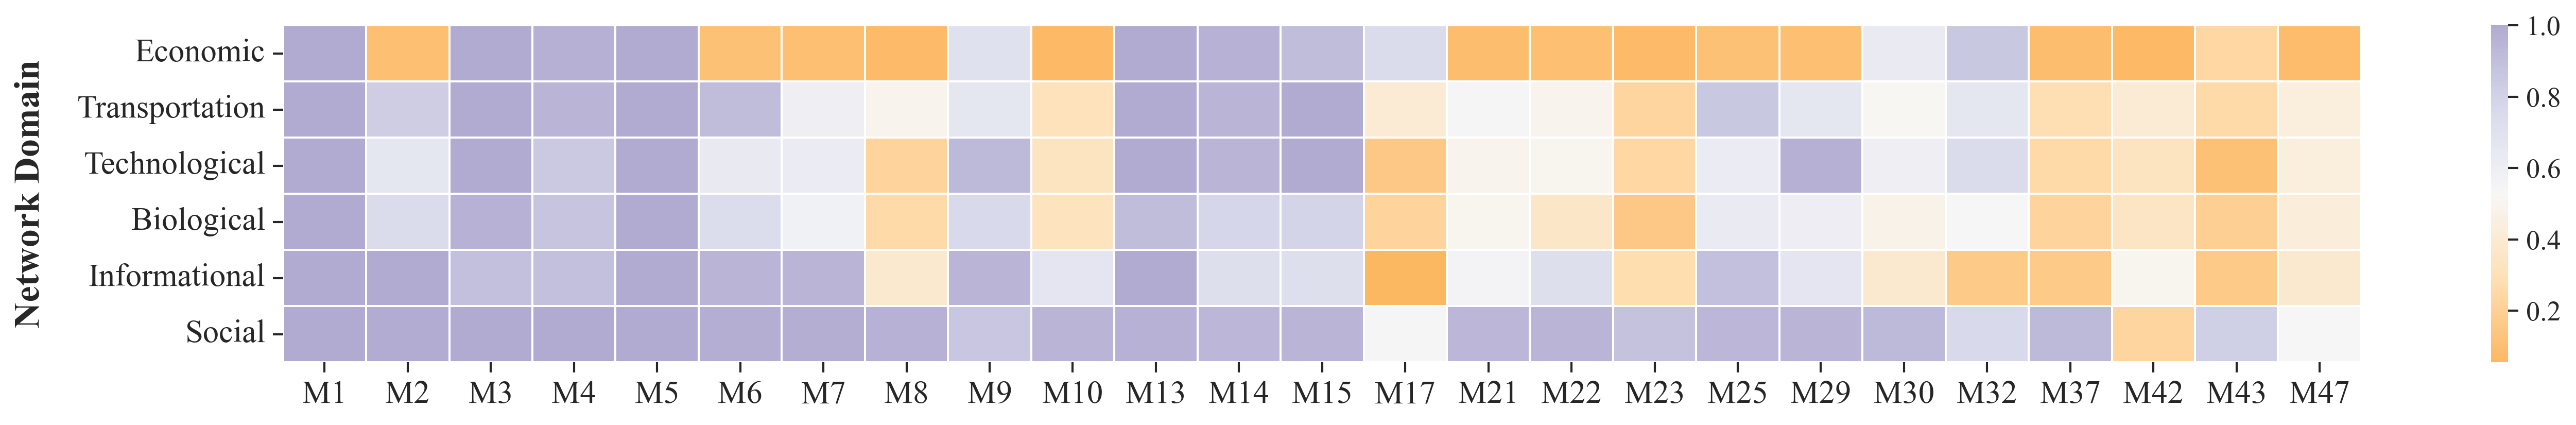

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import re
import numpy as np
import warnings

warnings.filterwarnings('ignore')

IS_DIR = r"D:\Orbit_degree_LP\jia\all_3_6\IS0313"
FEATURES_DIR = os.path.join(IS_DIR, "selected_M_features")

INFO_FILE = os.path.join(IS_DIR, "network_max_motif_classification.csv")

OUTPUT_IMG = os.path.join(IS_DIR, "domain_motif_fingerprint.png")
OUTPUT_PDF = os.path.join(IS_DIR, "domain_motif_fingerprint.pdf")

TOP_N_MOTIFS = 25 

TARGET_DOMAINS = [
    "Economic", 
    "Transportation", 
    "Technological",
    "Biological",  
    "Informational", 
    "Social"
]

def get_m_indices(file_path):
    if not os.path.exists(file_path): 
        return []
    try:
        df = pd.read_csv(file_path)

        if 'Selected_Features' not in df.columns:
            return []
            
        feats = df['Selected_Features'].tolist()
        indices = []
        for f in feats:
            match = re.search(r'\d+', str(f))
            if match: 
                indices.append(int(match.group()))
        return indices
    except Exception as e: 
        print(f"读取 {file_path} 失败: {e}")
        return []

def main():
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 15        
    plt.rcParams['axes.titlesize'] = 17     
    plt.rcParams['axes.labelsize'] = 17   
    plt.rcParams['xtick.labelsize'] = 15   
    plt.rcParams['ytick.labelsize'] = 15    

    if not os.path.exists(INFO_FILE):
        print(f"找不到包含领域信息的汇总表: {INFO_FILE}")
        return

    df_info = pd.read_csv(INFO_FILE)
    if 'network_domain' not in df_info.columns or 'Network' not in df_info.columns:
        print("INFO_FILE 中缺少 'Network' 或 'network_domain' 列！")
        return

    id_to_domain = dict(zip(df_info['Network'], df_info['network_domain']))

    domain_motif_counts = {}
    domain_sizes = {}
    
    for net_name, domain in id_to_domain.items():
        domain = str(domain).strip()
        if pd.isna(domain) or domain == 'nan' or domain == 'Unknown' or domain == '': 
            continue

        if domain not in domain_motif_counts:
            domain_motif_counts[domain] = {}
            domain_sizes[domain] = 0
            
        domain_sizes[domain] += 1

        f_path = os.path.join(FEATURES_DIR, f"{net_name}_selected_features.csv")
        
        m_indices = get_m_indices(f_path)
        for m in m_indices:
            domain_motif_counts[domain][m] = domain_motif_counts[domain].get(m, 0) + 1

    if not domain_motif_counts:
        print("没有提取到任何模体数据。")
        return

    df_counts = pd.DataFrame(domain_motif_counts).fillna(0).T
    df_freq = df_counts.copy()

    for domain in df_freq.index:
        size = domain_sizes.get(domain, 1)
        if size > 0:
            df_freq.loc[domain] = df_freq.loc[domain] / size

    motif_mean_freq = df_freq.mean(axis=0)
    top_motifs = motif_mean_freq.nlargest(TOP_N_MOTIFS).index.tolist()
    top_motifs.sort() 
    
    df_heatmap = df_freq[top_motifs]
    df_heatmap.columns = [f"M{c}" for c in df_heatmap.columns]

    valid_domains = [d for d in TARGET_DOMAINS if d in df_heatmap.index]
    df_heatmap = df_heatmap.loc[valid_domains]

    plt.figure(figsize=(19, 3), dpi=300)

    cmap_original = plt.get_cmap('PuOr')
    new_colors = cmap_original(np.linspace(0.3, 0.7, 256))
    custom_cmap = mcolors.ListedColormap(new_colors)

    ax = sns.heatmap(df_heatmap, annot=False, 
                cmap=custom_cmap,      
                linewidths=.5) 

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13) 

    plt.ylabel("Network Domain", labelpad=14, fontweight='bold')
    
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    #plt.savefig(OUTPUT_IMG, bbox_inches='tight')
    #plt.savefig(OUTPUT_PDF, bbox_inches='tight')
    print(f"热力图已保存: \n - {OUTPUT_IMG}\n - {OUTPUT_PDF}")
    plt.show()

if __name__ == "__main__":
    main()

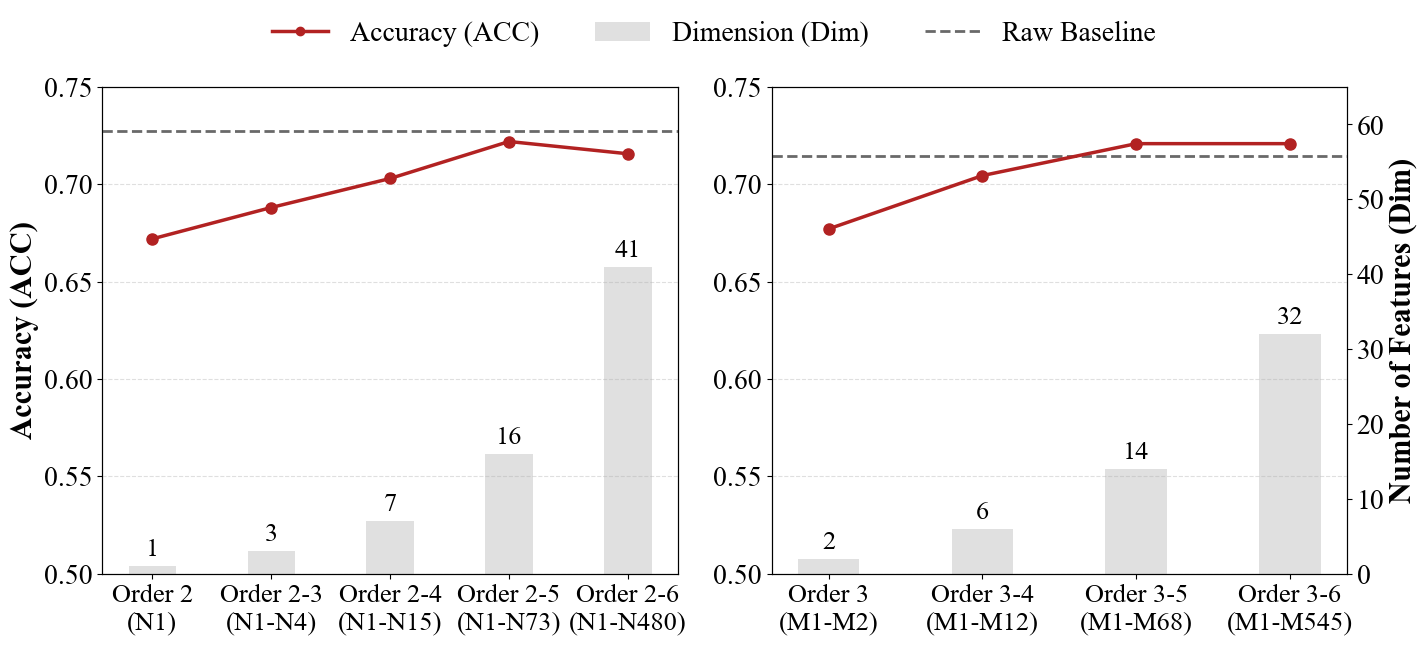

In [58]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

n_labels = ['Order 2\n(N1)', 'Order 2-3\n(N1-N4)', 'Order 2-4\n(N1-N15)', 'Order 2-5\n(N1-N73)', 'Order 2-6\n(N1-N480)']
n_dims = [1, 3, 7, 16, 41]
n_acc = [0.6720, 0.6881, 0.7030, 0.7220, 0.7157]
n_std = [0.0899, 0.1037, 0.1005, 0.0770, 0.0812]

m_labels = ['Order 3\n(M1-M2)', 'Order 3-4\n(M1-M12)', 'Order 3-5\n(M1-M68)', 'Order 3-6\n(M1-M545)']
m_dims = [2, 6, 14, 32]
m_acc = [0.6771, 0.7045, 0.7209, 0.7209]
m_std = [0.1026, 0.0912, 0.0765, 0.0818]
groups = [
    (n_labels, n_acc, n_std, n_dims, '(a) Node Orbit Features (N)'),
    (m_labels, m_acc, m_std, m_dims, '(b) Edge/Motif Orbit Features (M)')
]

baselines = [0.7274, 0.7146]
baseline_labels = ['Raw Baseline All (N1-N480): 0.7223', 'Raw Baseline All (M1-M545): 0.7103']

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

PERF_YLIM = (0.50, 0.75)
FEAT_YLIM = (0, 65)

for i, ax1 in enumerate(axes):
    labels, means, stds, feats, title = groups[i]
    x_pos = np.arange(len(labels))

    ax2 = ax1.twinx()
    bars = ax2.bar(x_pos, feats, color='lightgray', alpha=0.7, width=0.4)
    ax2.set_ylim(FEAT_YLIM)

    for tick in ax2.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(20)
        
    if i == 1:
        ax2.set_ylabel('Number of Features (Dim)', fontsize=22, fontweight='bold', fontname='Times New Roman')
    else:
        ax2.set_yticklabels([]) 
        ax2.tick_params(axis='y', length=0)

    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)
    
    line = ax1.errorbar(x_pos, means, yerr=None, fmt='-o', color='#B22222', 
                        ecolor='black', elinewidth=1.5, capsize=5, markersize=8, 
                        linewidth=2.5)

    baseline_y = baselines[i]
    ax1.axhline(y=baseline_y, color='dimgray', linestyle='--', linewidth=2, zorder=0)

    ax1.set_ylim(PERF_YLIM)

    for tick in ax1.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(20)
        
    if i == 0:
        ax1.set_ylabel('Accuracy (ACC)', fontsize=22, fontweight='bold', fontname='Times New Roman')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, fontsize=19, fontname='Times New Roman')
    # ax1.set_title(title, fontsize=16, fontweight='bold', fontname='Times New Roman', pad=15)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.4)

    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  
                     textcoords="offset points",
                     ha='center', va='bottom', 
                     fontsize=19,fontname='Times New Roman')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
custom_lines = [
    Line2D([0], [0], color='#B22222', marker='o', lw=2.5, label='Accuracy (ACC)'),
    Patch(facecolor='lightgray', alpha=0.7, label='Dimension (Dim)'),
    Line2D([0], [0], color='dimgray', linestyle='--', lw=2, label='Raw Baseline')
]

fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, 
           prop={'family': 'Times New Roman', 'size': 20}, frameon=False)

plt.tight_layout()
plt.savefig('D:\\Orbit_degree_LP\\jia\\all_3_6\\IS0313\\graph_ablation_orders.pdf', dpi=300, bbox_inches='tight')
plt.show()

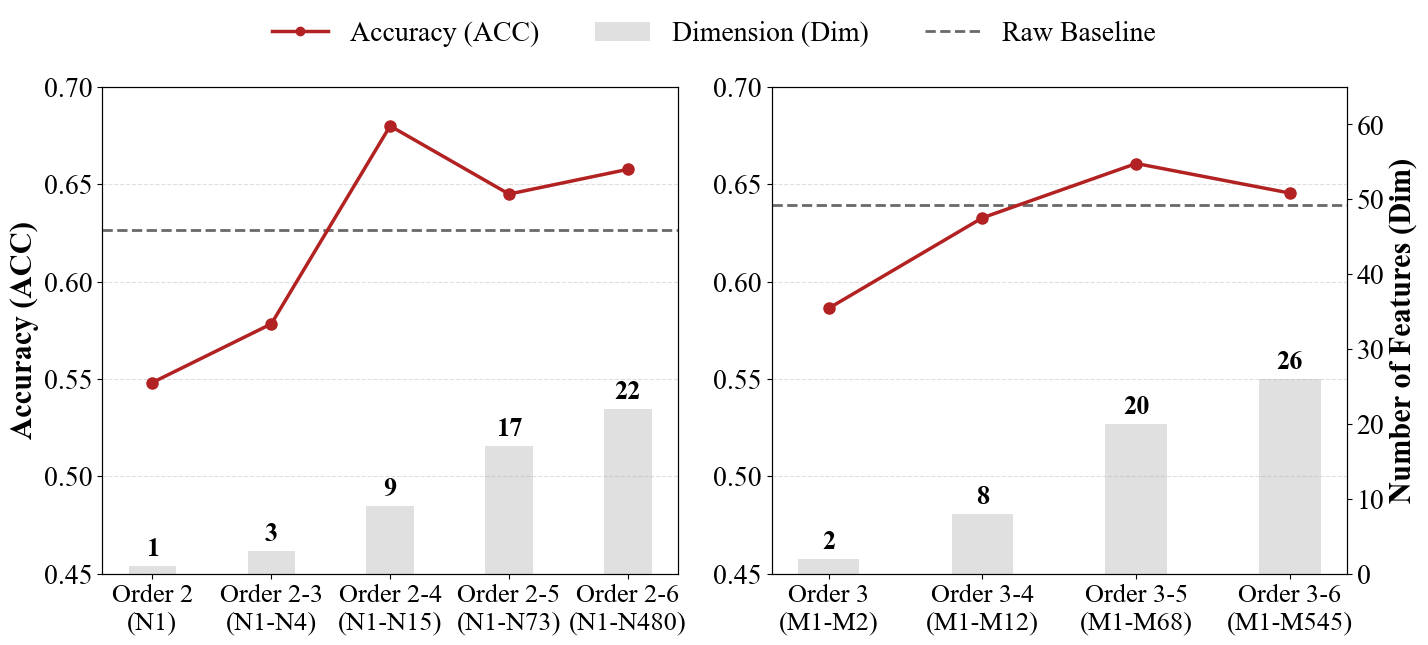

In [57]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

n_labels = ['Order 2\n(N1)', 'Order 2-3\n(N1-N4)', 'Order 2-4\n(N1-N15)', 'Order 2-5\n(N1-N73)', 'Order 2-6\n(N1-N480)']
n_dims = [1, 3, 9, 17, 22]
n_acc = [0.5482, 0.5783, 0.6800, 0.6450, 0.6577]
n_std = [0.0971, 0.0717, 0.0792, 0.0792, 0.0520]

m_labels = ['Order 3\n(M1-M2)', 'Order 3-4\n(M1-M12)', 'Order 3-5\n(M1-M68)', 'Order 3-6\n(M1-M545)']
m_dims = [2, 8, 20, 26]
m_acc = [0.5863, 0.6328, 0.6607, 0.6455]
m_std = [0.0913, 0.0995, 0.0789, 0.0765]
groups = [
    (n_labels, n_acc, n_std, n_dims, '(a) Node Orbit Features (N)'),
    (m_labels, m_acc, m_std, m_dims, '(b) Edge/Motif Orbit Features (M)')
]

baselines = [0.6265, 0.6393]
baseline_labels = ['Raw Baseline All (N1-N480): 0.7223', 'Raw Baseline All (M1-M545): 0.7103']

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

PERF_YLIM = (0.45, 0.7)
FEAT_YLIM = (0, 65)

for i, ax1 in enumerate(axes):
    labels, means, stds, feats, title = groups[i]
    x_pos = np.arange(len(labels))

    ax2 = ax1.twinx()
    bars = ax2.bar(x_pos, feats, color='lightgray', alpha=0.7, width=0.4)
    ax2.set_ylim(FEAT_YLIM)
    
    for tick in ax2.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(20)
        
    if i == 1:
        ax2.set_ylabel('Number of Features (Dim)', fontsize=22, fontweight='bold', fontname='Times New Roman')
    else:
        ax2.set_yticklabels([]) 
        ax2.tick_params(axis='y', length=0)

    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)
    
    line = ax1.errorbar(x_pos, means, yerr=None, fmt='-o', color='#B22222', 
                        ecolor='black', elinewidth=1.5, capsize=5, markersize=8, 
                        linewidth=2.5)

    baseline_y = baselines[i]
    ax1.axhline(y=baseline_y, color='dimgray', linestyle='--', linewidth=2, zorder=0)

    ax1.set_ylim(PERF_YLIM)

    for tick in ax1.get_yticklabels():
        tick.set_fontname('Times New Roman')
        tick.set_fontsize(20)
        
    if i == 0:
        ax1.set_ylabel('Accuracy (ACC)', fontsize=22, fontweight='bold', fontname='Times New Roman')

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, fontsize=19, fontname='Times New Roman')
    # ax1.set_title(title, fontsize=16, fontweight='bold', fontname='Times New Roman', pad=15)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.4)

    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  
                     textcoords="offset points",
                     ha='center', va='bottom', 
                     fontsize=19, fontweight='bold', fontname='Times New Roman')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
custom_lines = [
    Line2D([0], [0], color='#B22222', marker='o', lw=2.5, label='Accuracy (ACC)'),
    Patch(facecolor='lightgray', alpha=0.7, label='Dimension (Dim)'),
    Line2D([0], [0], color='dimgray', linestyle='--', lw=2, label='Raw Baseline') 
]

fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, 
           prop={'family': 'Times New Roman', 'size': 20}, frameon=False)

plt.tight_layout()
plt.savefig('D:\\Orbit_degree_LP\\jia\\all_3_6\\IS0313\\node_ablation_orders.pdf', dpi=300, bbox_inches='tight')
plt.show()

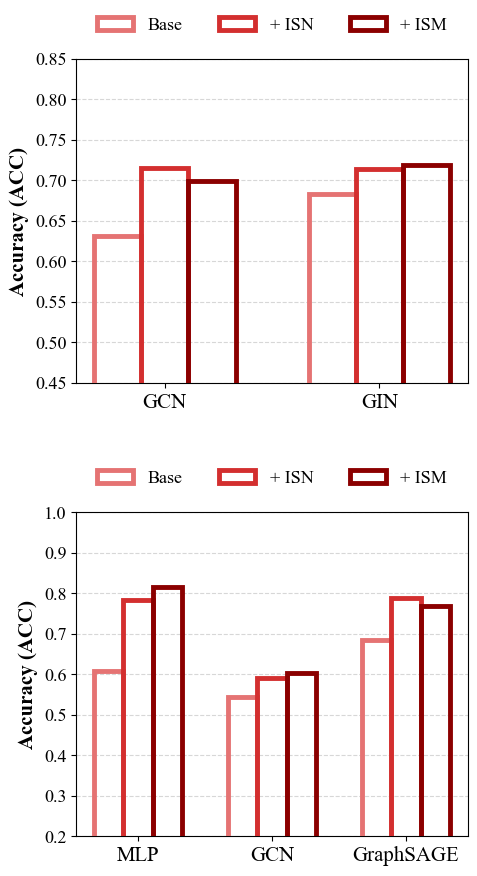

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

graph_models = ['GCN', 'GIN']
graph_base = [0.632, 0.683]
graph_isn = [0.715, 0.714]
graph_ism = [0.699, 0.719]

node_models = ['MLP', 'GCN', 'GraphSAGE']
node_base = [0.608, 0.544, 0.684]
node_isn = [0.783, 0.590, 0.789]
node_ism = [0.816, 0.603, 0.768]

color_base = '#E57373' 
color_isn = '#D32F2F' 
color_ism = '#8B0000'   

plt.rcParams['font.family'] = 'Times New Roman'  

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 9))
width = 0.22  
lw = 3.5      

x1 = np.arange(len(graph_models))

ax1.bar(x1 - width, graph_base, width, label='Base', 
        facecolor='none', edgecolor=color_base, linewidth=lw, zorder=3)
ax1.bar(x1, graph_isn, width, label='+ ISN', 
        facecolor='none', edgecolor=color_isn, linewidth=lw, zorder=3)
ax1.bar(x1 + width, graph_ism, width, label='+ ISM', 
        facecolor='none', edgecolor=color_ism, linewidth=lw, zorder=3)

ax1.set_ylabel('Accuracy (ACC)', fontweight='bold', fontsize=15)
ax1.set_xticks(x1)
ax1.set_xticklabels(graph_models, fontsize=15)
ax1.tick_params(axis='y', labelsize=13)

ax1.set_ylim(0.45, 0.85)  
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, frameon=False, prop={'size': 13})

x2 = np.arange(len(node_models))

ax2.bar(x2 - width, node_base, width, label='Base', 
        facecolor='none', edgecolor=color_base, linewidth=lw, zorder=3)
ax2.bar(x2, node_isn, width, label='+ ISN', 
        facecolor='none', edgecolor=color_isn, linewidth=lw, zorder=3)
ax2.bar(x2 + width, node_ism, width, label='+ ISM', 
        facecolor='none', edgecolor=color_ism, linewidth=lw, zorder=3)

ax2.set_ylabel('Accuracy (ACC)', fontweight='bold', fontsize=15)
ax2.set_xticks(x2)
ax2.set_xticklabels(node_models, fontsize=15)
ax2.tick_params(axis='y', labelsize=13)

ax2.set_ylim(0.2, 1.0)  
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, frameon=False, prop={'size': 13})

plt.tight_layout()

plt.subplots_adjust(top=0.92, hspace=0.4)

plt.savefig('D:\\Orbit_degree_LP\\jia\\all_3_6\\IS0313\\performance_comparison_hollow_blue.pdf', dpi=300, bbox_inches='tight')
plt.show()